# Projet de Scoring de Crédit : Prédiction du Défaut de Paiement
**Présenté par : [Sahli Wissem]**

## 1. Introduction
L'objectif de ce projet est de prédire le risque de défaut de paiement (`Status`) à partir d'un jeu de données bancaires complexe contenant 34 variables. 

### Problématique :
Comment identifier les facteurs discriminants (financiers et démographiques) qui permettent d'anticiper l'incapacité d'un emprunteur à rembourser son prêt ?

## 2. Chargement des données
Nous utilisons la bibliothèque `kagglehub` pour récupérer la version la plus récente du dataset "Loan Default Dataset".

Installation des bibliothèques nécessaires pour l'analyse de données, la gestion des datasets et le machine learning 

In [228]:
import sys
!{sys.executable} -m pip install dython missingno kagglehub pandas matplotlib seaborn scikit-learn imbalanced-learn scipy


In [229]:
import kagglehub
from pathlib import Path
import shutil
import os


# création du dossier local ( qui contiendra la base )

data_folder = Path('data')
data_folder.mkdir(exist_ok=True)

# téléchargement de la base avec Kaggle API

try : 
    path = Path(kagglehub.dataset_download("yasserh/loan-default-dataset"))
    print("Téléchargement de la dernière version réussi.")

    files = [ f for f in os.listdir(path) if f.endswith(".csv")]
    src_file = path / files[0]
    data = data_folder / "data.csv"

    shutil.copy(src_file , data )
    print(f"Fichier copié avec succès dans : {data}")

except Exception as e :
    print(f"Erreur : {e}")



Téléchargement de la dernière version réussi.
Fichier copié avec succès dans : data\data.csv


In [230]:
import pandas as pd 

df = pd.read_csv(data)
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## 3. Exploration et Nettoyage des Données

In [231]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [232]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

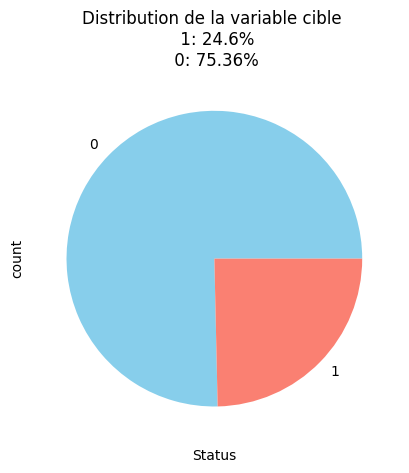

In [234]:
import matplotlib.pyplot as plt

df["Status"].value_counts().plot(kind='pie',colors=['skyblue','salmon'])
plt.title(f'Distribution de la variable cible \n 1: {(df["Status"]==1).mean()*100:.1f}%\n 0: {(df["Status"]==0).mean()*100:.2f}%')
plt.xlabel('Status')
plt.xticks(rotation=0)
plt.show()

## Les valeurs dupliquées

In [235]:
df = df.drop_duplicates()

## Création de la train_test Set

In [236]:
from sklearn.model_selection import train_test_split

X = df.drop('Status',axis=1)
y = df['Status']

X_train,X_test , y_train , y_test = train_test_split(X ,y,
                              test_size=0.2,
                              random_state=42,
                              stratify=df['Status'])
                              
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)                           

print("Proportion dans le Train :\n", y_train.value_counts(normalize=True))
print("\nProportion dans le Test :\n", y_test.value_counts(normalize=True))


Proportion dans le Train :
 Status
0    0.753557
1    0.246443
Name: proportion, dtype: float64

Proportion dans le Test :
 Status
0    0.753548
1    0.246452
Name: proportion, dtype: float64


## Les valeurs manquantes

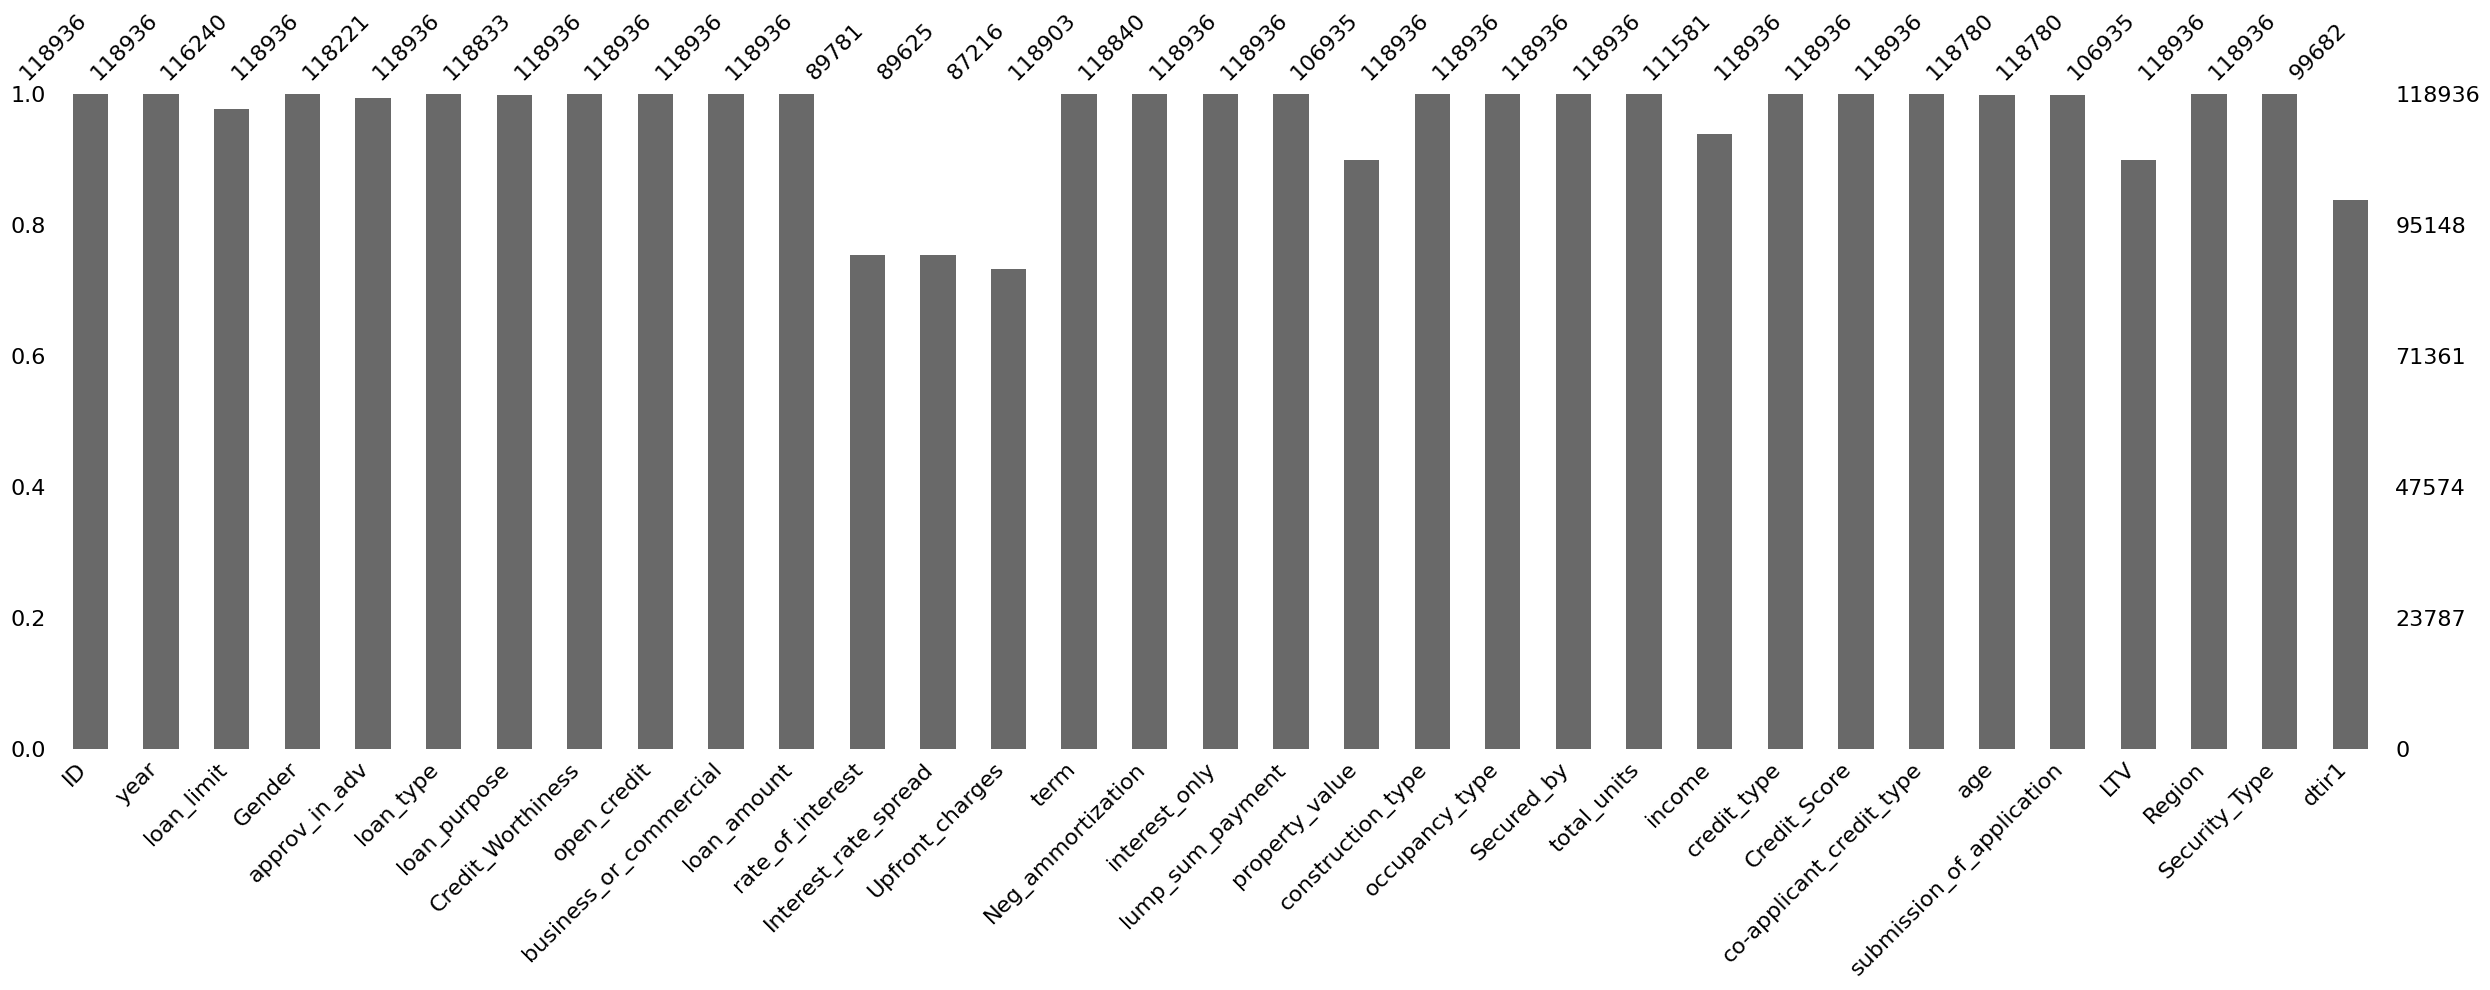

In [237]:
import missingno as msno
import matplotlib.pyplot as plt

msno.bar(X_train)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [238]:
print('Pourcentage des valeurs manquantes par colonnes : \n')

missing = (X_train.isnull().mean()*100).round(2).sort_values(ascending=False) 
print (missing[ missing > 0])


Pourcentage des valeurs manquantes par colonnes : 

Upfront_charges              26.67
Interest_rate_spread         24.64
rate_of_interest             24.51
dtir1                        16.19
property_value               10.09
LTV                          10.09
income                        6.18
loan_limit                    2.27
approv_in_adv                 0.60
submission_of_application     0.13
age                           0.13
loan_purpose                  0.09
Neg_ammortization             0.08
term                          0.03
dtype: float64


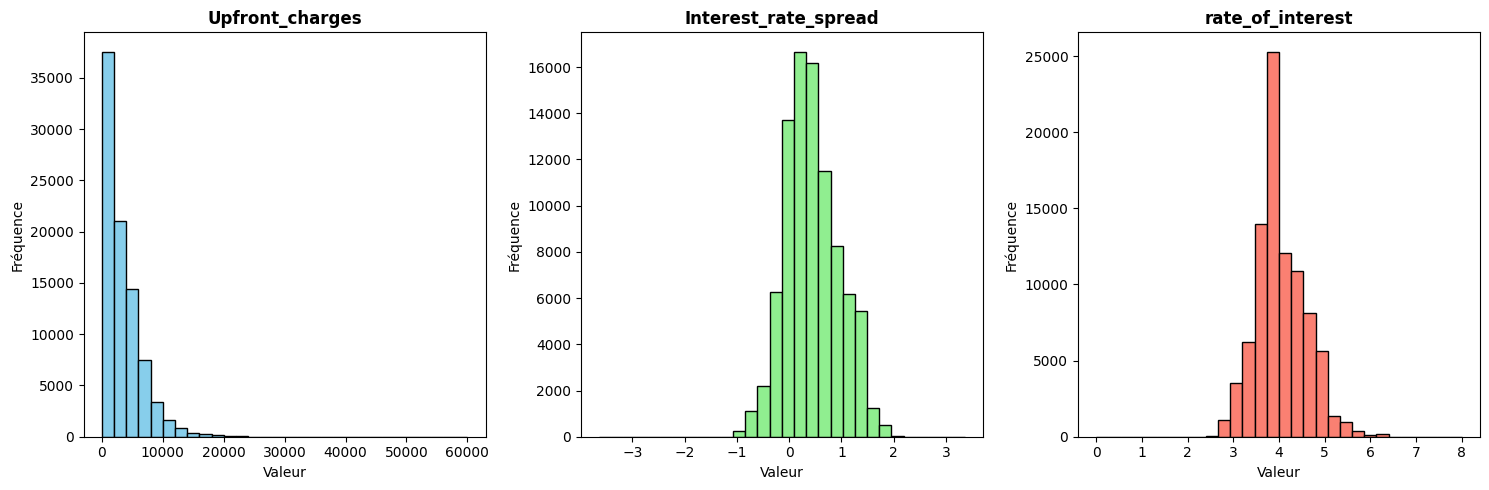

In [239]:
high_missing = ['Upfront_charges', 'Interest_rate_spread', 'rate_of_interest', 'dtir1', 'property_value', 'LTV']

import matplotlib.pyplot as plt

# Créer une figure avec 3 subplots (1 ligne, 3 colonnes)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Premier histogramme
axes[0].hist(X_train['Upfront_charges'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Upfront_charges', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valeur')
axes[0].set_ylabel('Fréquence')

# Deuxième histogramme
axes[1].hist(X_train['Interest_rate_spread'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Interest_rate_spread', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valeur')
axes[1].set_ylabel('Fréquence')

# Troisième histogramme
axes[2].hist(X_train['rate_of_interest'], bins=30, color='salmon', edgecolor='black')
axes[2].set_title('rate_of_interest', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Valeur')
axes[2].set_ylabel('Fréquence')

# Ajuster l'espacement entre les subplots
plt.tight_layout()
plt.show()

In [240]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer


# 1. Sélection des colonnes

num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

# 2. Imputation Numérique (Iterative)
numeric_imputer = IterativeImputer(max_iter=10, random_state=42)


X_train_num = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[num_cols]), 
    columns=num_cols, 
    index=X_train.index
)

# 3. Imputation Catégorielle (Most Frequent)
categorical_imputer = SimpleImputer(strategy="most_frequent")
X_train_cat = pd.DataFrame(
    categorical_imputer.fit_transform(X_train[cat_cols]), 
    columns=cat_cols, 
    index=X_train.index
)

# 4. Concatenation finale
X_train = pd.concat([X_train_num, X_train_cat], axis=1)

X_train['Upfront_charges'] = X_train['Upfront_charges'].clip(lower=0)

print("Imputation réussie et index synchronisés !")

Imputation réussie et index synchronisés !


## Les valeurs presques constantes

In [241]:
for i in X_train.columns:

    num_uniques = X_train[i].nunique()

    if num_uniques < 3:
        print(f"--- Variable : {i} ({num_uniques} valeurs uniques) ---")
        print(X_train[i].value_counts(), '\n')

--- Variable : year (1 valeurs uniques) ---
year
2019.0    118936
Name: count, dtype: int64 

--- Variable : loan_limit (2 valeurs uniques) ---
loan_limit
cf     110936
ncf      8000
Name: count, dtype: int64 

--- Variable : approv_in_adv (2 valeurs uniques) ---
approv_in_adv
nopre    100341
pre       18595
Name: count, dtype: int64 

--- Variable : Credit_Worthiness (2 valeurs uniques) ---
Credit_Worthiness
l1    113892
l2      5044
Name: count, dtype: int64 

--- Variable : open_credit (2 valeurs uniques) ---
open_credit
nopc    118490
opc        446
Name: count, dtype: int64 

--- Variable : business_or_commercial (2 valeurs uniques) ---
business_or_commercial
nob/c    102374
b/c       16562
Name: count, dtype: int64 

--- Variable : Neg_ammortization (2 valeurs uniques) ---
Neg_ammortization
not_neg    106784
neg_amm     12152
Name: count, dtype: int64 

--- Variable : interest_only (2 valeurs uniques) ---
interest_only
not_int     113286
int_only      5650
Name: count, dtype: int

In [242]:
print(X_train["Secured_by"].value_counts(),'\n')
print(X_train["Security_Type"].value_counts(),'\n')
print(X_train["construction_type"].value_counts(),'\n')

X_train = X_train.drop(columns=['Security_Type','Secured_by','construction_type'])

# Supprimer les colonnes inutiles ( id - year )
X_train = X_train.drop(columns=['ID','year'])

drop_col = ['Secured_by','Security_Type','construction_type','ID','year']

print("==> Supprimation finie des colonnes : ID - Year - Security - construction_type")


Secured_by
home    118913
land        23
Name: count, dtype: int64 

Security_Type
direct      118913
Indriect        23
Name: count, dtype: int64 

construction_type
sb    118913
mh        23
Name: count, dtype: int64 

==> Supprimation finie des colonnes : ID - Year - Security - construction_type


## Etude de Corrélation 

## Corrélation des variables numérique avec la variable cible "Status"

In [243]:
X_train['mensualite'] = X_train['loan_amount'] / X_train['term']

corr_matrix = pd.concat([X_train.select_dtypes(include=[np.number]),y_train],axis=1).corr()

corr_matrix['Status'].reindex(corr_matrix['Status'].abs().sort_values(ascending=False).index)


Status                  1.000000
dtir1                   0.064148
income                 -0.062756
property_value         -0.041312
loan_amount            -0.039143
mensualite             -0.037474
LTV                     0.025524
Interest_rate_spread    0.022579
rate_of_interest        0.006715
Upfront_charges        -0.004533
Credit_Score            0.003124
term                   -0.001802
Name: Status, dtype: float64

## Corrélation des variables catégorielle avec la variable cible "Status"

In [244]:
from scipy.stats import chi2_contingency

def cramer_v(x,y):
    confusion_matrix = pd.crosstab(x,y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r , k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

results = {}
for col in X_train.select_dtypes(exclude=[np.number]):
    results[col]= cramer_v(X_train[col],y_train)

results_series = pd.Series(results)
cramers_results = results_series.reindex(results_series.abs().sort_values(ascending = False).index)
print(cramers_results)


credit_type                  0.589992
lump_sum_payment             0.182587
Neg_ammortization            0.155654
co-applicant_credit_type     0.143305
submission_of_application    0.122629
loan_type                    0.093318
business_or_commercial       0.092146
Gender                       0.084349
loan_limit                   0.052885
Region                       0.049700
age                          0.048962
loan_purpose                 0.039951
approv_in_adv                0.037715
Credit_Worthiness            0.033999
occupancy_type               0.029128
total_units                  0.026661
interest_only                0.016076
open_credit                  0.009599
dtype: float64


## Solution donnée par DeepSeek !

Corrélation avec la variable cible

In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency

def correlation_avec_target_binaire(X, y):
    """
    Calcule les corrélations entre toutes les variables et une target binaire
    """
    results = []
    target_name = y.name if hasattr(y, 'name') else 'target'

    for col in X.columns:
        # 1. Traitement des variables NUMÉRIQUES
        if X[col].dtype in ['float64', 'int64']:
            # Point-biserial (Num vs Binaire)
            corr, p_val = pointbiserialr(y, X[col])
            results.append({
                'variable': col, 'type': 'numérique',
                'correlation': round(corr,3), 'p_value': p_val, 'abs_corr': abs(corr)
            })
            
        # 2. Traitement des variables CATÉGORIELLES
        else:
            contingency = pd.crosstab(X[col], y)
            # Sécurité pour les variables à modalité unique
            if min(contingency.shape) > 1:
                chi2, p_val, dof, expected = chi2_contingency(contingency)
                n = contingency.sum().sum()
                cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
                results.append({
                    'variable': col, 'type': 'catégorielle',
                    'correlation': round(cramers_v,3), 'p_value': p_val, 'abs_corr': cramers_v
                })

    df_results = (pd.DataFrame(results)).sort_values('abs_corr', ascending=False)

    return df_results.drop(columns=['abs_corr'])

# Utilisation
corr_results = correlation_avec_target_binaire(X_train, y_train)
print(corr_results)

                     variable          type  correlation        p_value
23                credit_type  catégorielle        0.590   0.000000e+00
20           lump_sum_payment  catégorielle        0.183   0.000000e+00
18          Neg_ammortization  catégorielle        0.156   0.000000e+00
24   co-applicant_credit_type  catégorielle        0.143   0.000000e+00
26  submission_of_application  catégorielle        0.123   0.000000e+00
13                  loan_type  catégorielle        0.093  4.599419e-226
17     business_or_commercial  catégorielle        0.092  7.810890e-222
11                     Gender  catégorielle        0.084  9.249511e-184
9                       dtir1     numérique        0.064  1.155737e-108
6                      income     numérique       -0.063  4.501990e-104
10                 loan_limit  catégorielle        0.053   1.550952e-74
27                     Region  catégorielle        0.050   4.960564e-64
25                        age  catégorielle        0.049   6.544

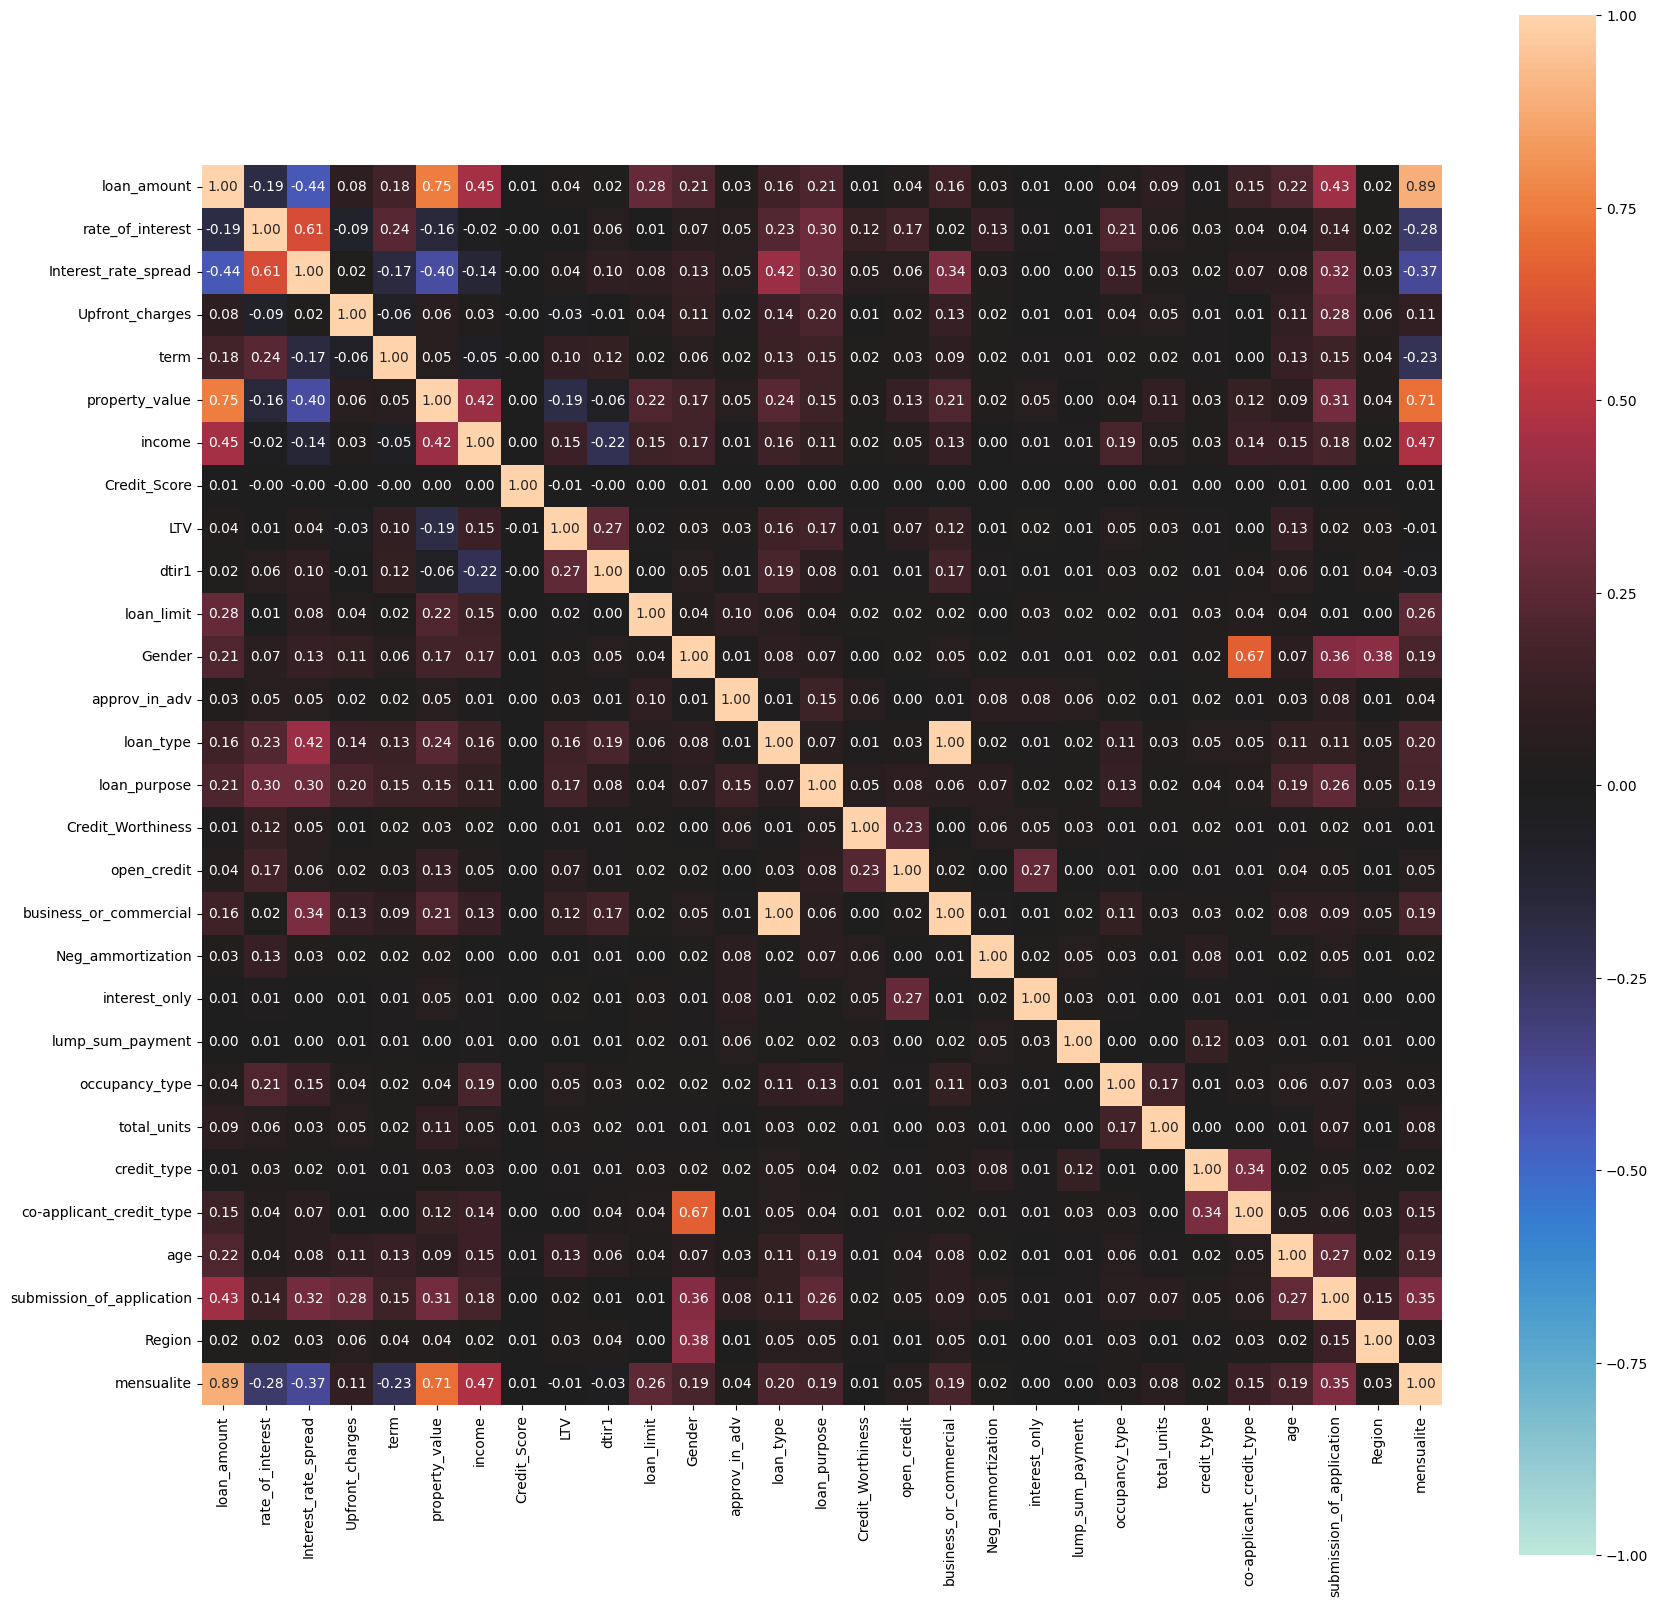

In [246]:
from dython.nominal import associations

_ = associations(X_train, figsize=(20, 20), cbar=True)

### Probléme de colinéarité parfaite (>0.9) !

In [247]:
print(f"Corrélation entre 'business_or_commercial' et 'loan_type' : {cramer_v(X_train['business_or_commercial'],X_train['loan_type'])}")
print("==> Corrélation Parfaite\n")
print("loan_type : 0.0938 (p-value: 3.5 x 10^{-285})")
print('business_or_commercial : 0.0925 (p-value: 9.1 x 10^{-279})')
print("==> On supprime la variable 'business_or_commercial'.")

X_train = X_train.drop(columns=['business_or_commercial'])

drop_col += ['business_or_commercial']

Corrélation entre 'business_or_commercial' et 'loan_type' : 0.9999957959788537
==> Corrélation Parfaite

loan_type : 0.0938 (p-value: 3.5 x 10^{-285})
business_or_commercial : 0.0925 (p-value: 9.1 x 10^{-279})
==> On supprime la variable 'business_or_commercial'.


### Variables "Inutiles" ( faible Corrélation + forte P-Value )

À ce stade, nous avons choisi de conserver l'ensemble des variables. En effet, bien que certaines présentent une corrélation linéaire faible, des modèles non linéaires comme le Random Forest ou XGBoost sont capables de capturer des interactions complexes et des relations non-linéaires que les tests statistiques classiques ne décèlent pas.

## QQs Visualisations

In [248]:
# Création d'un dataset temporaire pour la visualisation

train_eda = X_train.copy()
train_eda['Status'] = y_train.values

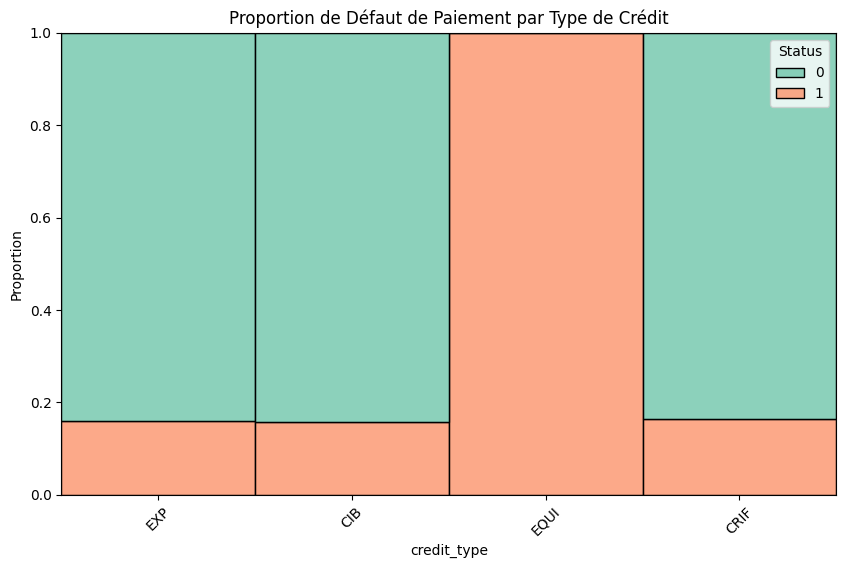

In [249]:
plt.figure(figsize=(10, 6))
sns.histplot(data=train_eda, x='credit_type', hue='Status', multiple="fill", palette='Set2')
plt.title("Proportion de Défaut de Paiement par Type de Crédit")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

In [250]:
X_train['credit_type'].value_counts()

credit_type
CIB     38567
CRIF    35111
EXP     33100
EQUI    12158
Name: count, dtype: int64

- CIB (Credit Information Bureau) : Un bureau de données qui centralise l'historique de crédit des emprunteurs pour évaluer leur solvabilité avant l'octroi d'un prêt.

- CRIF (Centrale de Risques Financiers) : Un système international spécialisé dans la gestion du risque de crédit et les solutions de Business Information pour le secteur bancaire.

- EXP (Experian) : L'un des trois plus grands bureaux de crédit mondiaux, fournissant des scores de risque basés sur l'historique de paiement et l'endettement.

- EQUI (Equifax) : Une agence globale d'évaluation du crédit qui regroupe les données financières pour produire des rapports de solvabilité utilisés par les prêteurs.

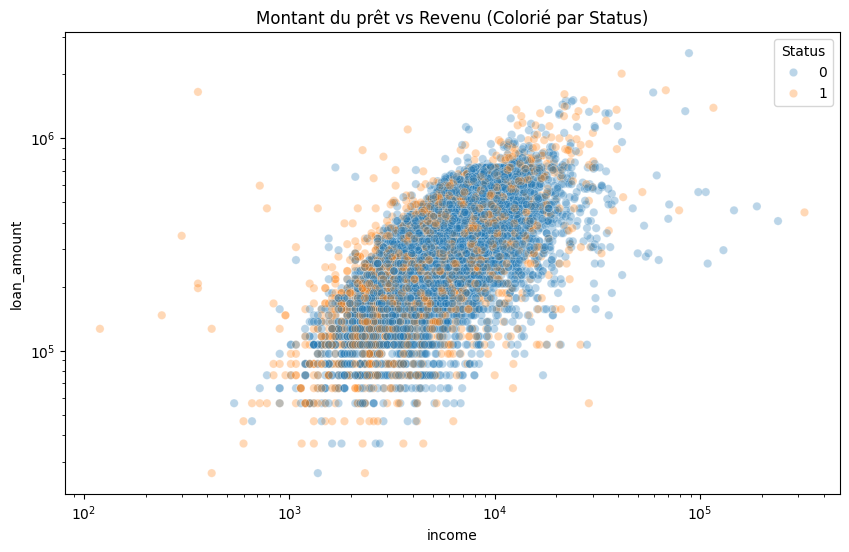

In [251]:
plt.figure(figsize=(10, 6))
# On utilise un échantillon si le dataset est trop gros pour éviter que les points ne se chevauchent trop
sns.scatterplot(data=train_eda.sample(min(10000, len(train_eda))), 
                x='income', y='loan_amount', hue='Status', alpha=0.3)
plt.title("Montant du prêt vs Revenu (Colorié par Status)")
plt.xscale('log') # Souvent nécessaire pour l'argent
plt.yscale('log')
plt.show()

## Gestion des Attributs Textuels et Catégoriels 

In [252]:
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("Modalitées des variables catégoriels")

X_train.select_dtypes(exclude=['float64', 'int64']).nunique()

Modalitées des variables catégoriels


loan_limit                   2
Gender                       4
approv_in_adv                2
loan_type                    3
loan_purpose                 4
Credit_Worthiness            2
open_credit                  2
Neg_ammortization            2
interest_only                2
lump_sum_payment             2
occupancy_type               3
total_units                  4
credit_type                  4
co-applicant_credit_type     2
age                          7
submission_of_application    2
Region                       4
dtype: int64

### La stratégie d'encodage 

In [253]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

ordinal_encoder = OrdinalEncoder()
onehot_encoder =OneHotEncoder(sparse_output=False, handle_unknown='ignore')

all_cat = X_train.select_dtypes(exclude=['float64', 'int64']).columns.tolist()

ordinal_feat = ['age','Credit_Worthiness']
onehot_feat = [col for col in all_cat if col not in ordinal_feat]

X_train_ohe = pd.DataFrame(
    onehot_encoder.fit_transform(X_train[onehot_feat]),
    columns=onehot_encoder.get_feature_names_out(onehot_feat),
    index=X_train.index
)
X_train_ord = pd.DataFrame(
    ordinal_encoder.fit_transform(X_train[ordinal_feat]),
    columns=ordinal_feat,
    index=X_train.index
)

X_train_num = X_train.select_dtypes(include=['float64', 'int64'])
X_train = pd.concat([X_train_num, X_train_ohe, X_train_ord], axis=1)

print(f"Dimensions finales : {X_train.shape}")
type(X_train)


Dimensions finales : (118936, 55)


pandas.core.frame.DataFrame

## Distrubition des variables numériques

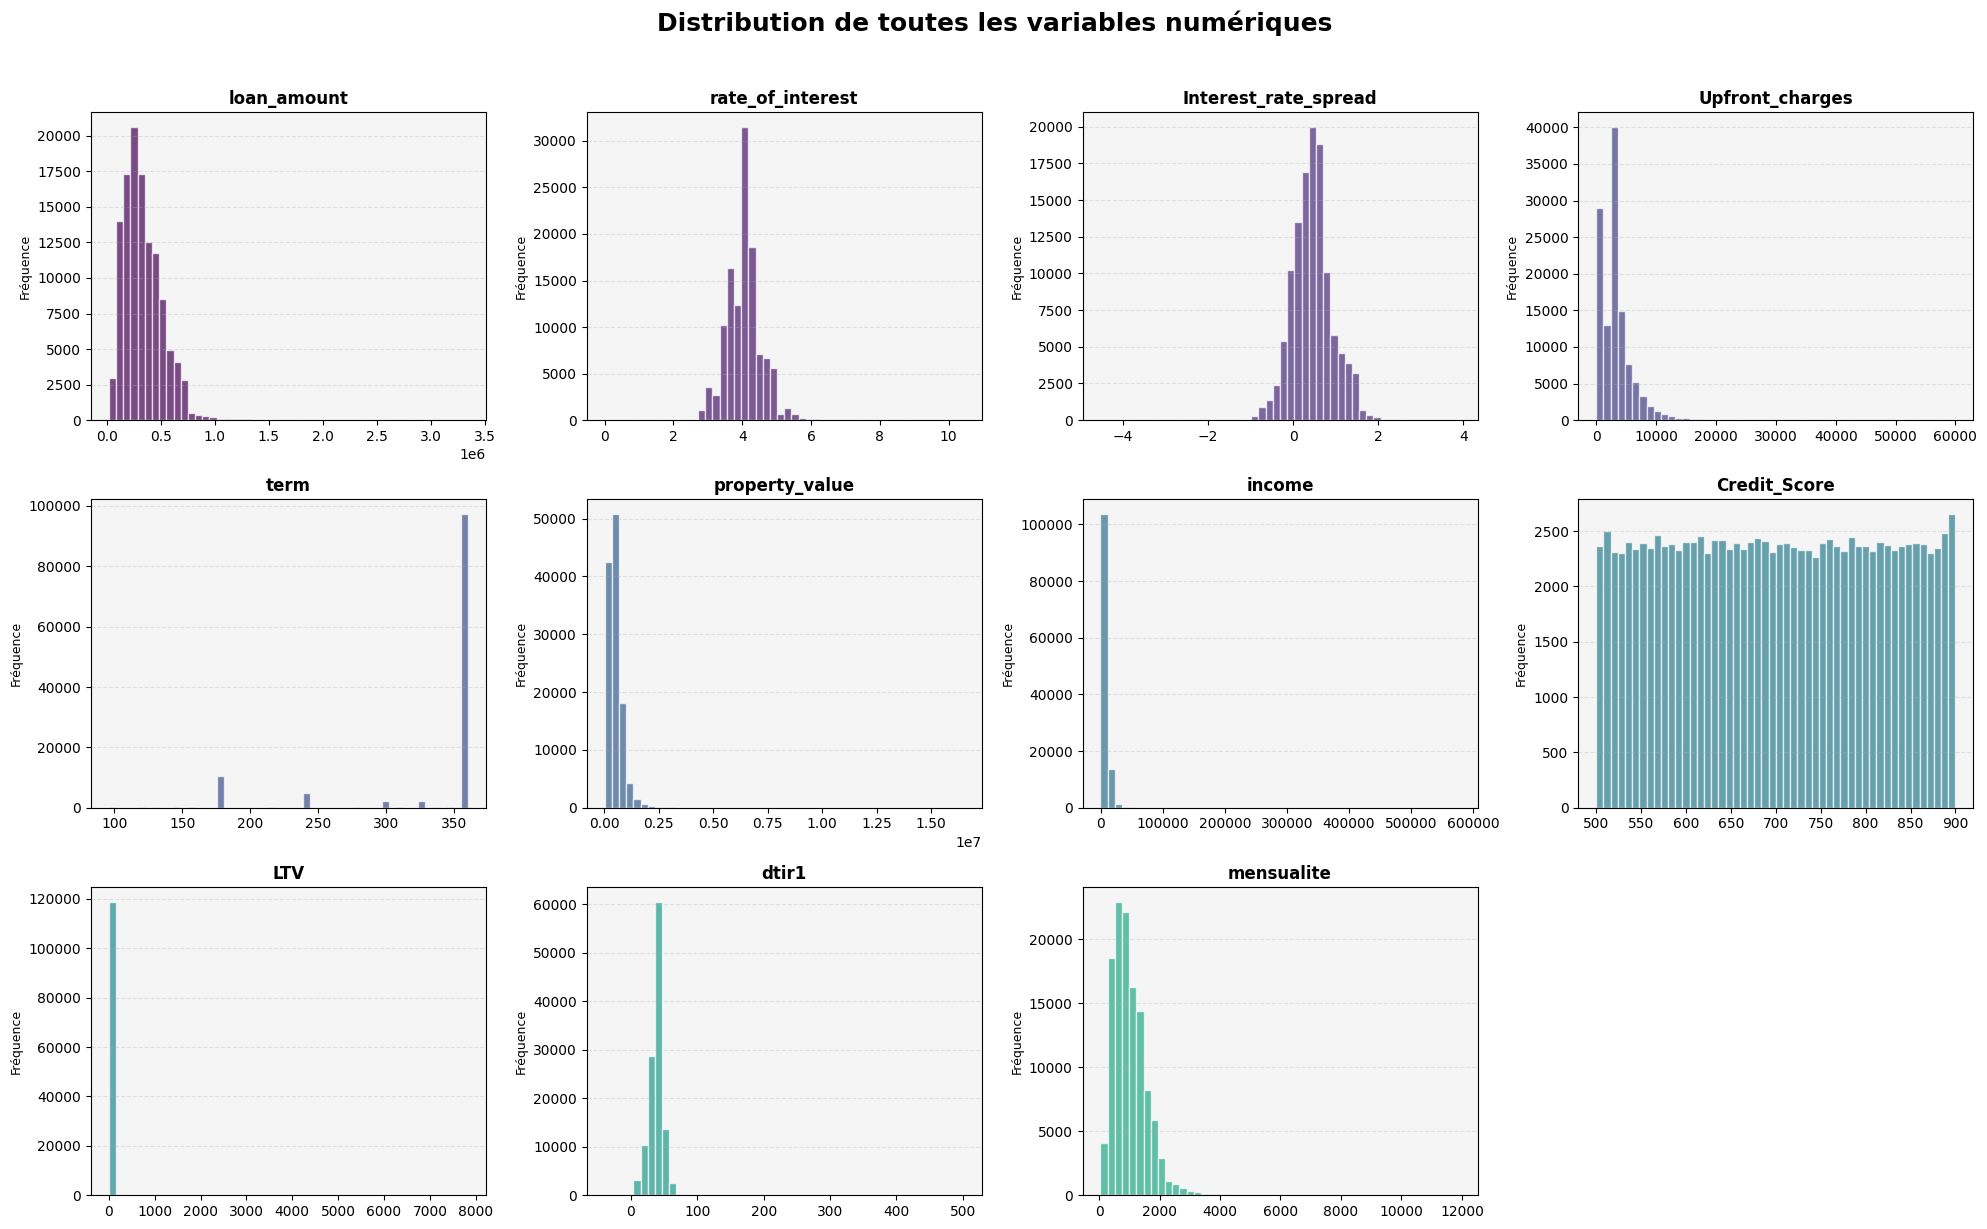

In [254]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Sélectionner uniquement les colonnes numériques
cols_num = num_cols
n_cols = len(cols_num)

# 2. Calculer le nombre de lignes/colonnes pour la grille
n_subplot_cols = 4
n_subplot_rows = (n_cols + n_subplot_cols - 1) // n_subplot_cols

# 3. Créer UNE SEULE figure
fig, axes = plt.subplots(n_subplot_rows, n_subplot_cols, figsize=(20, 4 * n_subplot_rows))
axes = axes.flatten() # Aplatir pour itérer facilement

# 4. Palette de couleurs (une couleur différente par plot)
colors = plt.cm.viridis(np.linspace(0, 0.6, n_cols))

# 5. Boucle pour tracer chaque histogramme manuellement
for i, col in enumerate(cols_num):
    ax = axes[i]
    X_train[col].hist(ax=ax, bins=50, color=colors[i], edgecolor='white', alpha=0.7, grid=False)
    
    # Personnalisation
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.set_facecolor('#f5f5f5')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylabel('Fréquence', fontsize=9)

# 6. Supprimer les subplots vides si nécessaire
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution de toutes les variables numériques', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### transformation

c:\Users\wgsom\anaconda3\envs\langchain_env\lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


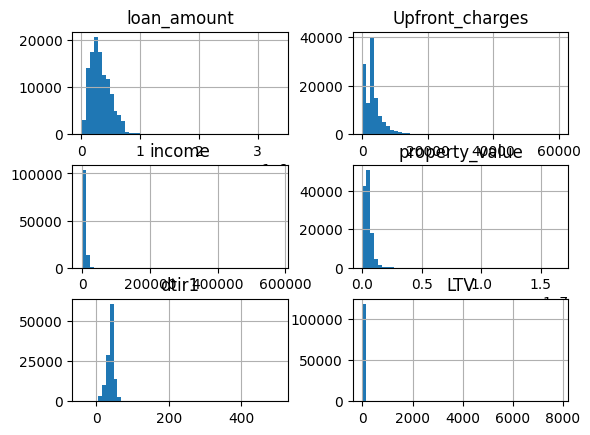

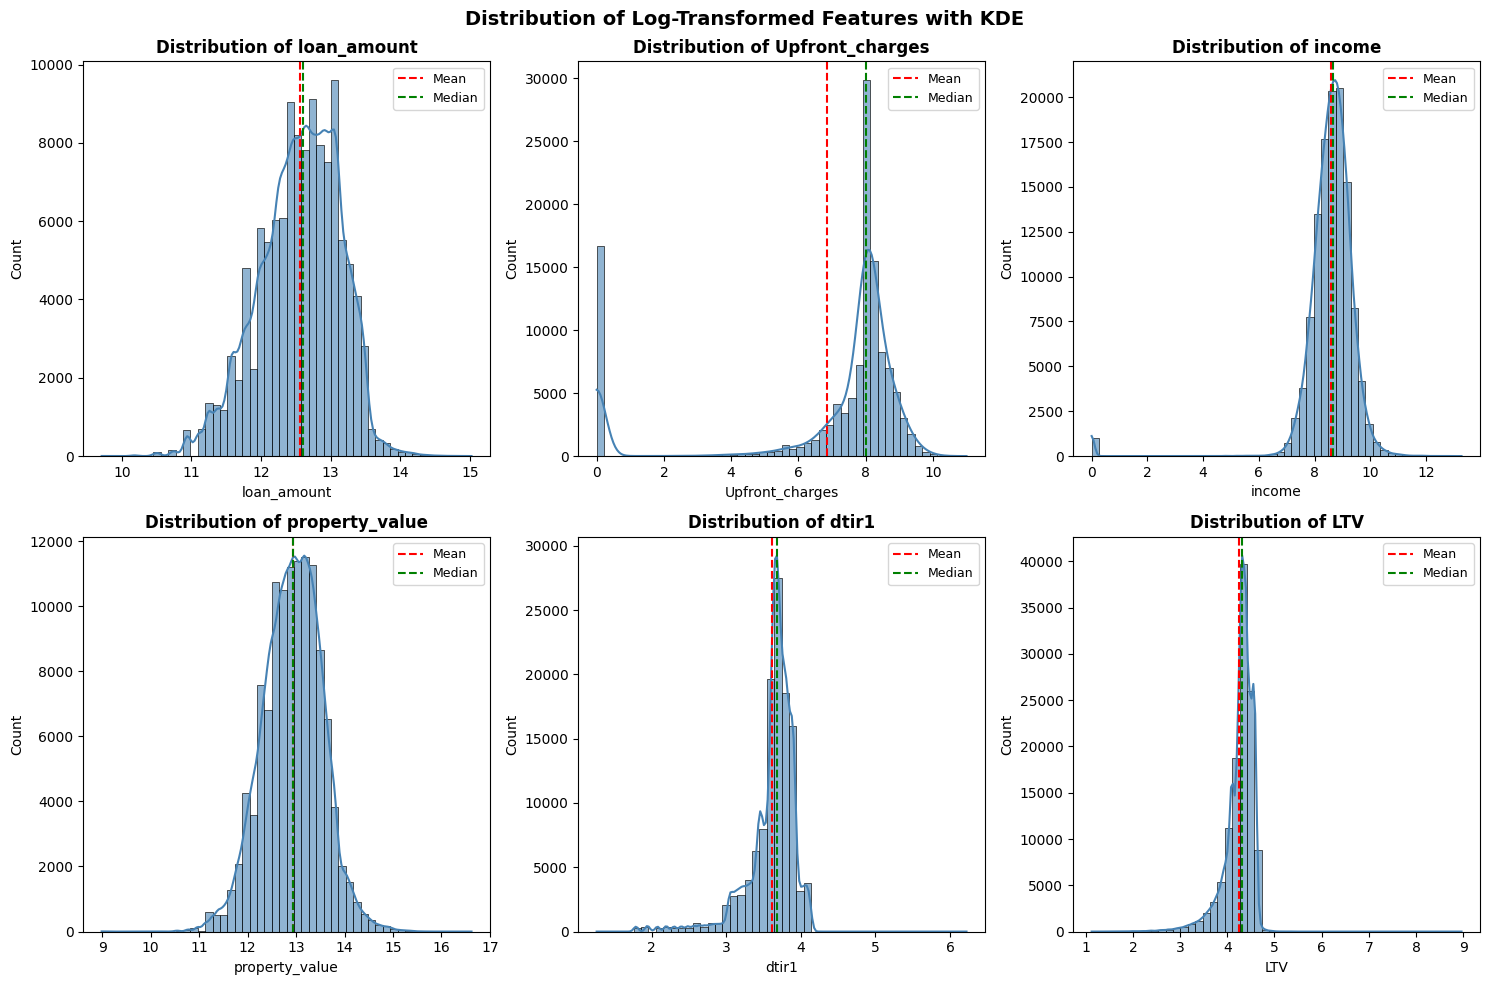

In [255]:
from sklearn.preprocessing import FunctionTransformer


log_trans_col = ['loan_amount','Upfront_charges','income','property_value','dtir1','LTV']
X_train[log_trans_col].hist(bins = 50)

log_transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1)

X_train[log_trans_col] = log_transformer.fit_transform(X_train[log_trans_col])



""" -------- Code for better visualization -------- """

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(log_trans_col):
    sns.histplot(data=X_train, x=col, bins=50, kde=True, ax=axes[idx], 
                 color='steelblue', edgecolor='black', alpha=0.6)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].axvline(x=X_train[col].mean(), color='red', linestyle='--', 
                      linewidth=1.5, label=f'Mean')
    axes[idx].axvline(x=X_train[col].median(), color='green', linestyle='--', 
                      linewidth=1.5, label=f'Median')
    axes[idx].legend(fontsize=9)

plt.suptitle('Distribution of Log-Transformed Features with KDE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Pour la variable "term"

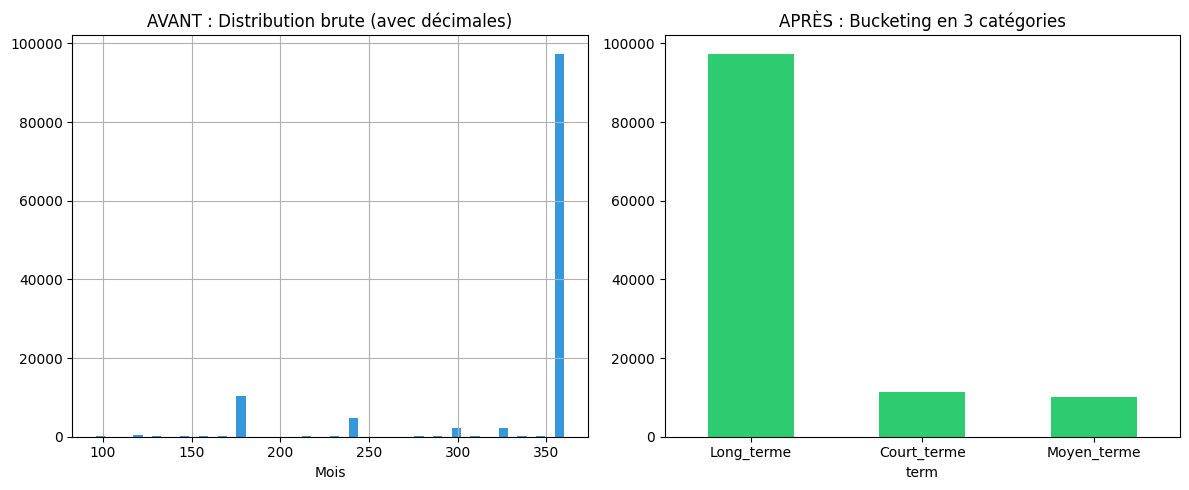

In [256]:
def bucketize_term(X):
    bins = [0, 180, 359, np.inf]
    labels = ['Court_terme', 'Moyen_terme', 'Long_terme']

    X_binned = pd.cut(X.iloc[:, 0], bins=bins, labels=labels).astype(str).to_frame()
    return X_binned

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
X_train['term'].hist(bins=50, color='#3498db')
plt.title("AVANT : Distribution brute (avec décimales)")
plt.xlabel("Mois")

term_transf = FunctionTransformer(bucketize_term)
X_train["term"] = term_transf.fit_transform(X_train[['term']])

plt.subplot(1, 2, 2)
X_train['term'].value_counts().plot(kind='bar', color='#2ecc71')
plt.title("APRÈS : Bucketing en 3 catégories")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Feature Scaling

In [257]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


